👁️ ¿Qué es la visión artificial?

La visión artificial es una tecnología que permite que las computadoras y las máquinas “vean” y comprendan imágenes o videos mediante cámaras, sensores y programas de inteligencia artificial.

En palabras sencillas: la visión artificial hace que una máquina pueda analizar lo que aparece frente a una cámara y tomar decisiones a partir de esa información.

⚙️ ¿Cómo funciona?

Generalmente funciona mediante estos pasos:

📷 Captura: una cámara toma una fotografía o graba un video.
💻 Procesamiento: el sistema procesa la imagen y elimina o reduce información que no necesita.
🔍 Análisis: la inteligencia artificial identifica objetos, personas, formas, colores, textos o movimientos.
🧠 Interpretación: el sistema determina qué está viendo.
✅ Acción: según el resultado, puede generar una alerta, clasificar un objeto, contar elementos o controlar una máquina.

Ejemplo:
Una fábrica utiliza una cámara para revisar botellas. La visión artificial puede detectar si una botella está rota o si tiene la etiqueta mal colocada y separarla automáticamente.

📱 ¿Qué aplicaciones tiene?

La visión artificial se utiliza en muchos campos:

Área	Aplicación
🏭 Industria	Detectar productos defectuosos y controlar la calidad
🚗 Transporte	Sistemas de asistencia al conductor y reconocimiento de señales
🏥 Medicina	Ayudar a analizar imágenes médicas
🌾 Agricultura	Detectar enfermedades en plantas y controlar cultivos
🛒 Comercio	Analizar productos y facilitar sistemas de inventario
🔐 Seguridad	Detectar objetos o situaciones determinadas mediante cámaras
📱 Celulares	Reconocimiento facial, filtros y lectura de códigos
🏫 Educación	Reconocimiento de textos e imágenes para herramientas educativas
♻️ Medio ambiente	Clasificar residuos y detectar cambios en ecosistemas



🌟 Ejemplo de la vida cotidiana

Cuando un celular reconoce una cara para desbloquearse, está utilizando técnicas relacionadas con la visión artificial. La cámara captura la imagen y el sistema analiza características del rostro para determinar si corresponde a la persona registrada.

En resumen: la visión artificial combina cámaras + procesamiento de imágenes + inteligencia artificial para que las máquinas puedan interpretar información visual y actuar de acuerdo con ella.

Deteccion de rostro con python usando OpenCV 

a detección de rostros en Python usando OpenCV esLo más común es que se logre utilizando un modelo preentrenado llamado cascada de Haar.Implementación paso a pasoInstala OpenCV: Ejecútalo pip install opencv-pythonen tu terminal.Convertir a escala de grises: La detección de objetos funciona de forma más rápida y precisa en imágenes en escala de grises.Aplicar el clasificador: Utilice la detectMultiScalefunción para encontrar las coordenadas de las caras.Dibujar rectángulos: Itera a través de las coordenadas y dibuja los límites alrededor de las caras detectadas.

In [1]:
#1 . Instalacion de OpenCv Library 

#pip install opencv-python

#2. Importacion de la libreria OpenCv
import cv2

#3. Cargar la imagen
imgpath = 'img.jpg'

#4. Leer la imagen 
img = cv2.imread(imgpath)

# 5. Mostrar la imagen
img.shape



(384, 576, 3)

In [2]:
#6 Convertir la imagen a escala de grises 
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img.shape

(384, 576)

In [3]:
# 7.cargar el claseificador de datos 
cascade = "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

#8. Veriificar si el clasificador se cargo correctamente 
if face_cascade.empty():
    print("Error no se pudo cargar, verifica el xml")
else :
    print("Clasificador en cascada cargado correctamente")

Clasificador en cascada cargado correctamente


In [4]:
#9 . Se realiza la deteccion del rostro en la imagen en escala de girses . para ellos se hace uso de la funcion detectMultiscale(), esta se utiliza para detectar caras diferentes tamaños en la imagen de entrada 

face = face_cascade.detectMultiScale(gray_img,scaleFactor=1.1,minNeighbors=5,minSize=(40,40))

In [5]:
#10 For para recoger todas las caras y dibujar un rectangulo sobre la imagen original (img)

for (x,y,w,h) in face:
    cv2.rectangle(img,(x,y),(x+w,y+h),(255, 0, 0),2)

In [6]:
#11. las imagenes se cargan en BRG, se debe convertir a RBG
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

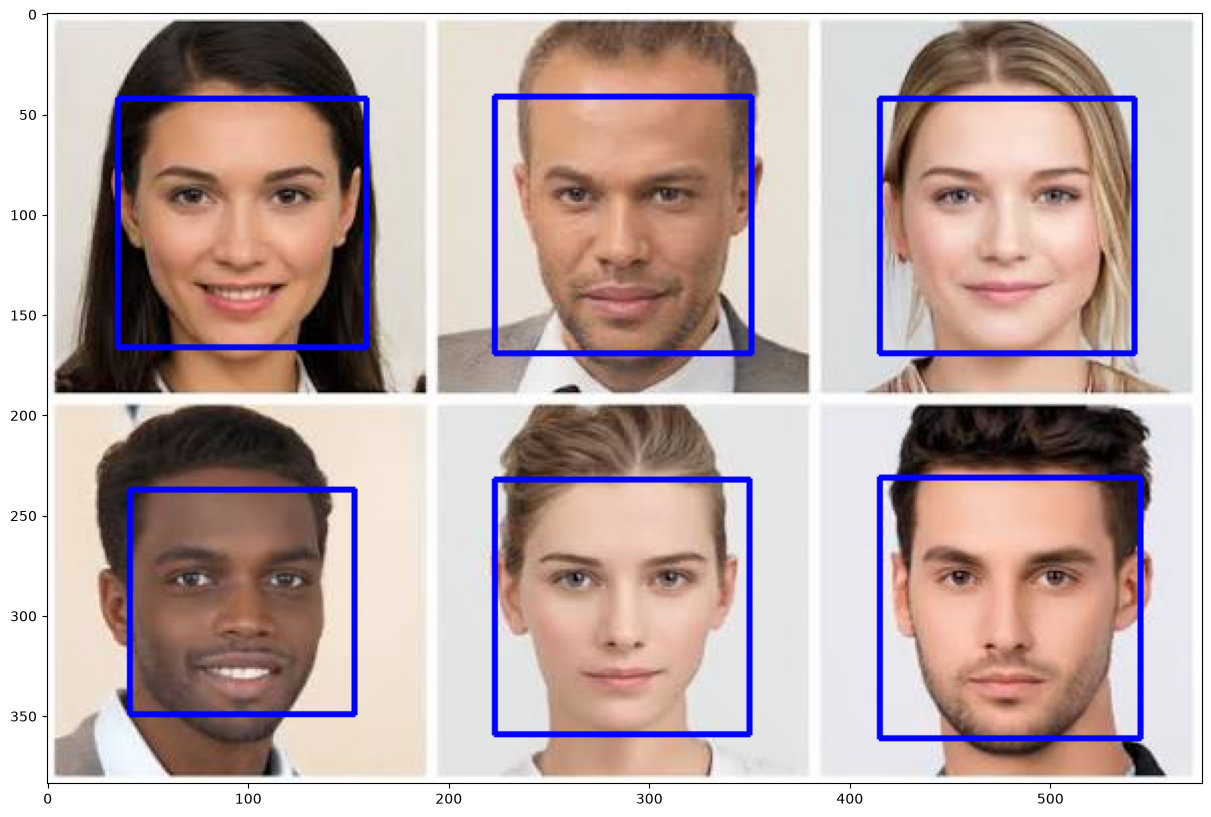

In [7]:
#12. Importar matplotlib

import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.imshow(img)

In [8]:
print("version",cv2.__version__)
print("CascadeClassifier",hasattr(cv2, 'CascadeClassifier'))

version 5.0.0
CascadeClassifier True


In [9]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:


pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip unistall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless

%pip install opencv-contrib-python==5.0.0.93

Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "unistall" - maybe you meant "uninstall"



Note: you may need to restart the kernel to use updated packages.


## Captura de video en tiempo real 


In [12]:
#1. Acceder a la camara de nuestro pc y leer un flujo de datos en tiempo real.
video_capture = cv2.VideoCapture(0)

# 2.Funcion para capturar el rostro con flujo de video y dibujar un reacuadro delimitador 

def detect_bounding_box(vid):
    gray_img = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, 1.1, minSize=(40, 40))
    for (x, y, w, h) in faces:
        cv2.rectangle(vid, (x, y), (x + w, y + h), (255, 0, 0), 2)
    return faces 

In [13]:
#3. bucle while para detectar caras en Real Time,capturar fotograma y aplicar detenccion de rostros 

while True:

    result, video_frame = video_capture.read()

    if result is False:
        break 
    faces= detect_bounding_box(video_frame)


    cv2.imshow("Mi cara detectada",video_frame)
    if cv2.waitKey(2) & 0xFF == ord('q'):
        break
  
video_capture.release()
cv2.destroyAllWindows()